## Loading the PEFT Library
This library contains the Hugging Face implementation of various Fine-Tuning techniques, including Prompt Tuning

In [ ]:
#!pip install -q peft transformers
#!pip install -q transformers

In [ ]:
#!pip uninstall -y datasets transformers huggingface_hub
#!pip install transformers==4.40.2 datasets==2.19.1 huggingface_hub==0.23.4

In [1]:
import sys
!{sys.executable} -m pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 125.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 120.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 146.1 MB/s  0:00:020:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 159.9 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 204.5 MB/s  0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 200.1 MB/s  0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 163.7 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 202.3 MB/s  0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 102.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 174.6 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 106.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 166.5 MB

In [2]:
import sys
!{sys.executable} -m pip install peft huggingface_hub datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 16.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 24.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 131.8 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 104.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [peft]2m18/19 [peft]erate]s]lizer]


In [3]:
import sys
!{sys.executable} -m pip install huggingface_hub

In [4]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 90.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 67.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 74.9 MB/s  0:00:04:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 131.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 22.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 23.9 MB/s  0:00:00m0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 94.4 MB/s  0:00:03:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 191.8 MB/s  0:00:0100:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 188.7 MB/s  0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 187.8 MB/s  0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 200.7 MB/s  0:00:0000:0100:01
   

In [12]:

import sys
!{sys.executable} -m pip install bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 137.4 MB/s  0:00:00m0:00:0100:01


From the transformers library, we import the necessary classes to instantiate the model and the tokenizer.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

### Loading the model and the tokenizers.

Bloom is one of the smallest and smartest models available for training with the PEFT Library using Prompt Tuning. You can choose any model from the Bloom Family, and I encourage you to try at least two of them to observe the differences.

I'm opting for the smallest one to minimize training time and avoid memory issues in Colab.

In [56]:
import torch
torch.cuda.empty_cache()

In [66]:
model_name = "HuggingFaceH4/zephyr-7b-beta"
#model_name = "meta-llama/Llama-3.2-3B-Instruct"

#model_name="bigscience/bloom-1b1"
NUM_VIRTUAL_TOKENS = 50
NUM_EPOCHS = 5

In [67]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
foundational_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [68]:
tokenizer.pad_token = tokenizer.eos_token

In [69]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=False,
)

foundational_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.padding_side = 'right'
tokenizer.pad_token = tokenizer.eos_token
tokenizer.add_special_tokens({'eos_token': '[EOS]', 'bos_token': '[BOS]'})



foundational_model.config.use_cache = False
foundational_model.config.pretraining_tp = 1
foundational_model.gradient_checkpointing_enable()


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

## Inference with the pre trained bloom model
If you want to achieve more varied and original generations, uncomment the parameters: temperature, top_p, and do_sample, in *model.generate* below

With the default configuration, the model's responses remain consistent across calls.

In [70]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

foundational_model.to(device)

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
     

In [71]:
#this function returns the outputs from the model received, and inputs.
def get_outputs(model, inputs, max_new_tokens=100):
    # Move input tensors to the same device as the model
    input_ids = inputs["input_ids"].to(model.device)
    attention_mask = inputs["attention_mask"].to(model.device)

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        #temperature=0.2,
        #top_p=0.95,
        #do_sample=True,
        repetition_penalty=1.5, #Avoid repetition.
        early_stopping=True, #The model can stop before reach the max_length
        eos_token_id=tokenizer.eos_token_id
    )
    return outputs

As we want to have two different trained models, I will create two distinct prompts.

The first model will be trained with a dataset containing prompts, and the second one with a dataset of motivational sentences.

The first model will receive the prompt "I want you to act as a motivational coach." and the second model will receive "There are two nice things that should matter to you:"

But first, I'm going to collect some results from the model without Fine-Tuning.

In [72]:
input_prompt = tokenizer("** How can we monitor and store download time within the Cisco device and configure IP and application layer options for optimal performance?. ", return_tensors="pt")
foundational_outputs_prompt = get_outputs(foundational_model, input_prompt, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_prompt, skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:32000 for open-end generation.


["** How can we monitor and store download time within the Cisco device and configure IP and application layer options for optimal performance?. \n** Answer: To effectively manage network traffic, it's essential to have visibility into how data is being transmitted across your infrastructure. This includes monitoring factors such as bandwidth usage, packet loss rates, latency levels, jitter values ("]


In [73]:
input_sentences = tokenizer("There are two nice things that should matter to you:", return_tensors="pt")
foundational_outputs_sentence = get_outputs(foundational_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:32000 for open-end generation.


["There are two nice things that should matter to you: the first is a new study from researchers at UC Berkeley, and it’s about how we can make our cities more livable. The second thing? It'll cost us nothing extra—and in fact will save money for both individuals ("]


## Preparing the Datasets



In [19]:
import sys
!{sys.executable} -m pip install gdown
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [gdown]32m2/4 [beautifulsoup4]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 76.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 126.8 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 116.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 99.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [ ]:
import gdown

file_id = "1QgcViAnotZxW3nWqsl00iTQQVAU8s8Wg" 
gdown.download(f"https://drive.google.com/uc?id={file_id}", "requirements_questions.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1QgcViAnotZxW3nWqsl00iTQQVAU8s8Wg
To: /workspace/requirements_questions.csv
100%|██████████| 4.38M/4.38M [00:00<00:00, 30.2MB/s]


'requirements_questions.csv'

In [21]:
from datasets import load_dataset

# Load the dataset from the CSV file
dataset_questions = load_dataset("csv", data_files="requirements_questions.csv")

# Create the Dataset from the 'configuration' column
# Assuming the column for text is 'configuration'
data_questions = dataset_questions.map(lambda samples: tokenizer(samples["answer"]), batched=True)

# You can display a sample to verify
# display(train_sample_questions)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5096 [00:00<?, ? examples/s]

In [ ]:
split_dataset = data_questions["train"].train_test_split(test_size=0.1, seed=42)
split_dataset = data_questions["train"].train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

print(f"Tamaño del conjunto de entrenamiento: {len(train_dataset)} muestras")
print(f"Tamaño del conjunto de prueba: {len(test_dataset)} muestras")


Tamaño del conjunto de entrenamiento: 4586 muestras
Tamaño del conjunto de prueba: 510 muestras


In [29]:
display(train_dataset)

Dataset({
    features: ['question', 'answer', 'input_ids', 'attention_mask'],
    num_rows: 4586
})

In [30]:
print(train_dataset[:1])

{'question': ['To enable monitoring of IPv6 fields and use all other Flexible Netflow commands not supported in the previous release on Cisco ASR 1000 Series Aggregation Services routers, what command should you use?'], 'answer': ['To achieve this requirement, you can configure the following command:\n\nRouter# configure terminal\nRouter(config)# ip flow-export version 9\n\nThis command enables monitoring of IPv6 fields and uses all other Flexible Netflow commands not supported in the previous release on Cisco ASR 1000 Series Aggregation Services routers running Cisco IOS XE Release 3.5S.\n\nNote: This configuration is specific to the Cisco ASR 1K series routers, which require the ip flow-export version 9 command to support IPv6 and Flexible Netflow features.'], 'input_ids': [[1, 1791, 6619, 456, 16169, 28725, 368, 541, 20919, 272, 2296, 3445, 28747, 13, 13, 16907, 28771, 20919, 17598, 13, 16907, 28732, 2241, 28731, 28771, 8465, 4699, 28733, 12707, 2751, 28705, 28774, 13, 13, 3260, 344

## Fine-Tuning.  

### PEFT configurations


API docs:
https://huggingface.co/docs/peft/main/en/package_reference/tuners#peft.PromptTuningConfig



In [74]:
from peft import  get_peft_model, PromptTuningConfig, TaskType, PromptTuningInit

generation_config = PromptTuningConfig(
    task_type=TaskType.CAUSAL_LM, #This type indicates the model will generate text.
    prompt_tuning_init=PromptTuningInit.RANDOM,  #The added virtual tokens are initializad with random numbers
    num_virtual_tokens=NUM_VIRTUAL_TOKENS, #Number of virtual tokens to be added and trained.
    tokenizer_name_or_path=model_name #The pre-trained model.
)


### Creating  Prompt Tuning Models.


In [75]:
peft_model_prompt = get_peft_model(foundational_model, generation_config)
print(peft_model_prompt.print_trainable_parameters())

trainable params: 204,800 || all params: 7,241,936,896 || trainable%: 0.0028
None


In [76]:
peft_model_sentences = get_peft_model(foundational_model, generation_config)
print(peft_model_sentences.print_trainable_parameters())

trainable params: 204,800 || all params: 7,241,936,896 || trainable%: 0.0028
None


**That's amazing: did you see the reduction in trainable parameters? We are going to train a 0.001% of the paramaters available.**

Now we are going to create the training arguments, and we will use the same configuration in both trainings.

In [77]:
from transformers import TrainingArguments
def create_training_arguments(path, learning_rate=0.005, epochs=5):
    training_args = TrainingArguments(
        output_dir=path, # Where the model predictions and checkpoints will be written
        use_cpu=False, # Set to False to enable GPU usage if available
        auto_find_batch_size=True, # Find a suitable batch size that will fit into memory automatically
        learning_rate= learning_rate, # Higher learning rate than full Fine-Tuning
        num_train_epochs=epochs,
        logging_steps=3, # Log metrics at every step
        report_to='none' # Do not report to any external service
    )
    return training_args

In [83]:

import os

working_dir = "./"

#Is best to store the models in separate folders.
#Create the name of the directories where to store the models.
output_directory_prompt =  os.path.join(working_dir, "peft_outputs_prompt_netconfig")
output_directory_sentences = os.path.join(working_dir, "peft_outputs_sentences")

#Just creating the directoris if not exist.
if not os.path.exists(working_dir):
    os.mkdir(working_dir)
if not os.path.exists(output_directory_prompt):
    os.mkdir(output_directory_prompt)
if not os.path.exists(output_directory_sentences):
    os.mkdir(output_directory_sentences)


We need to indicate the directory containing the model when creating the TrainingArguments.

In [79]:
training_args_prompt = create_training_arguments(output_directory_prompt, 0.005, NUM_EPOCHS)
training_args_sentences = create_training_arguments(output_directory_sentences, 0.005, NUM_EPOCHS)

## Train

We will create the trainer Object, one for each model to train.  

In [80]:
from transformers import Trainer, DataCollatorForLanguageModeling
def create_trainer(model, training_args, train_dataset):
    trainer = Trainer(
        model=model, # We pass in the PEFT version of the foundation model, bloomz-560M
        args=training_args, #The args for the training.
        train_dataset=train_dataset, #The dataset used to train the model.
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False) # mlm=False indicates not to use masked language modeling
    )
    return trainer

In [81]:
import time

start_time = time.time()

trainer_prompt = create_trainer(peft_model_prompt, training_args_prompt, train_dataset)
trainer_prompt.train()

end_time = time.time()

training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

training_time_seconds = training_time  # from earlier

cost = (training_time_seconds / 3600) * 4.42

print(f"Training cost: ${cost:.4f}")


Step,Training Loss
3,1.739946
6,1.523578
9,1.625017
12,1.617185
15,1.604619
18,1.497729
21,1.346041
24,1.407018
27,1.259453
30,1.133482


Training time: 1369.67 seconds
Training time: 22.83 minutes
Training cost: $1.6817


## plot results

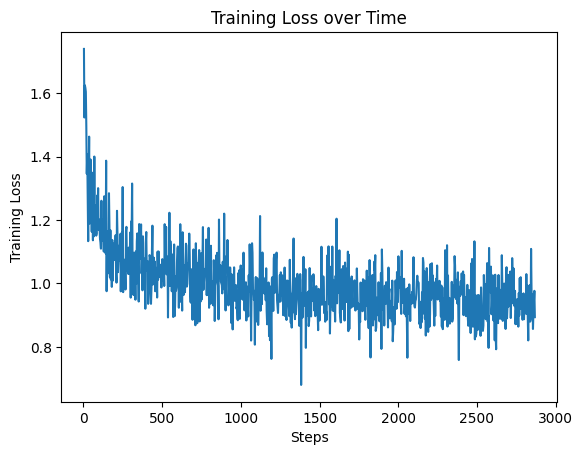

In [82]:
import  matplotlib.pyplot as plt
# -------------------------
# 5. Extract logs
# -------------------------
logs = trainer_prompt.state.log_history

train_loss = []
steps = []

for log in logs:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])

# -------------------------
# 6. Plot loss
# -------------------------
plt.figure()
plt.plot(steps, train_loss)
plt.xlabel("Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss over Time")
plt.show()

In [84]:
trainer_prompt.model.save_pretrained(output_directory_prompt)

In [ ]:
#thanks